In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import dft, idft

from hybridqsp.thresholding import (
    top_k_threshold,
    magnitude_threshold
)

from hybridqsp.metrics import (
    state_fidelity,
    trace_distance
)

Text(0.5, 1.0, 'Sinusoidal function')

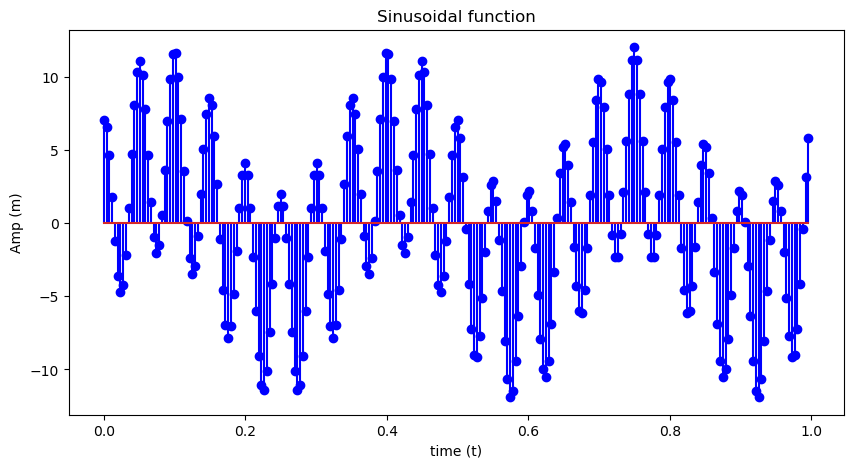

In [24]:
srate = 256  # sampling rate Hz

# time interval
t = np.arange(0. , 1. ,1/srate)

x1 = 5 * np.sin(2 * np.pi *3* t) # First sinewave
x2 = 7 * np.cos(2 * np.pi * 20 * t) # Third sinewave


x =  x1 + x2


plt.figure(figsize=(10,5))
plt.stem(t,x, "bo")
plt.xlabel("time (t)")
plt.ylabel("Amp (m)")
plt.title("Sinusoidal function")

In [25]:
X = dft(x)

In [38]:
freqs = np.fft.fftfreq(len(X), d=1/srate)

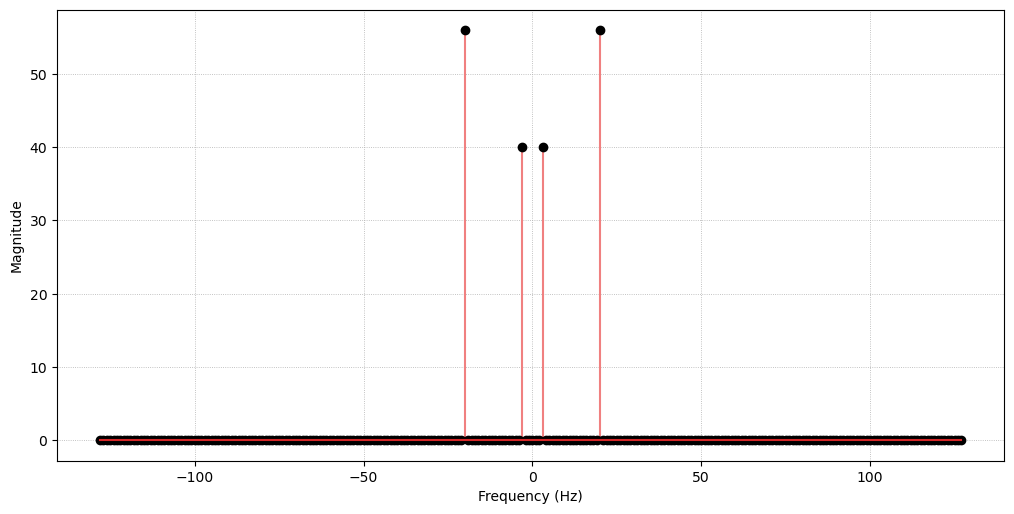

In [42]:
# Your existing time and signals
plt.figure(figsize=(10,5))  # smaller height for paper

# Plot original (thicker)
plt.stem(freqs, np.abs(X), linefmt="lightcoral", markerfmt="ko")
# Labels and grid
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, linestyle=':', linewidth=0.6)

# Tidy up layout
plt.tight_layout(pad=0.2)
plt.savefig("../figures/fourier_spectrum.png", dpi=300)
plt.show()

In [27]:
X_norm = X/np.linalg.norm(X)

# Checking the normalization of x_norm
np.linalg.norm(X_norm)

np.float64(0.9999999999999999)

In [30]:
x_rec = idft(X_norm).real

In [34]:
x_norm = x/np.linalg.norm(x)

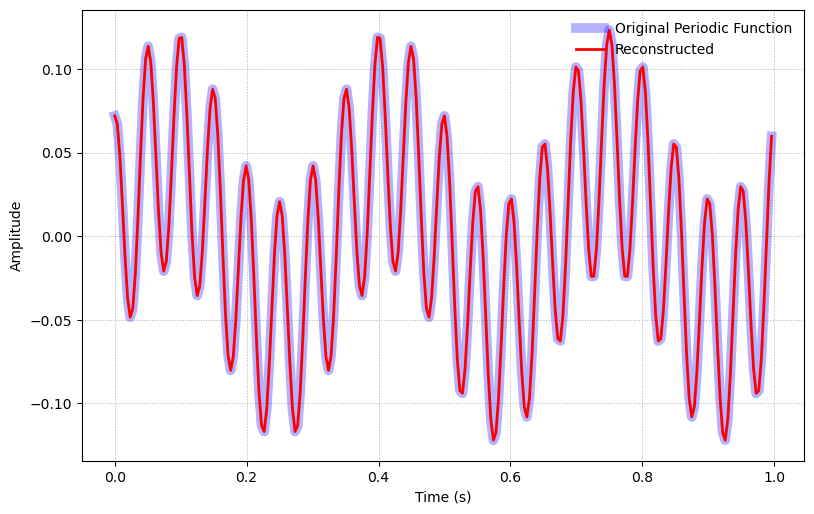

In [45]:
# Your existing time and signals
plt.figure(figsize=(8,5))  # smaller height for paper

# Plot original (thicker)
plt.plot(t, x_norm, label="Original Periodic Function", color='blue', lw=7, alpha=0.3)

# Plot reconstructed (dashed, slightly thinner)
plt.plot(t, x_rec, label="Reconstructed", linewidth=2, color="red")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=':', linewidth=0.7)

# Add legend (best location based on content)
plt.legend(loc='upper right', frameon=False)

# Tidy up layout
plt.tight_layout(pad=0.2)

# Optional save for LaTeX
plt.savefig("../figures/figuressignal_comparison.pdf")

plt.show()

In [36]:
F = state_fidelity(x_norm, x_rec)

D = trace_distance(x_norm, x_rec)